<a href="https://colab.research.google.com/github/rybak97/free_courses/blob/main/Data_Augmentation_BOK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Based on: https://www.datacamp.com/tutorial/complete-guide-data-augmentation

What Is Data Augmentation?\
Data augmentation is a technique of artificially increasing the training set by creating modified copies of a dataset using existing data. It includes making minor changes to the dataset or using deep learning to generate new data points.

# Example in Keras

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

## Data import

In [2]:
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

## Dataset check

In [3]:
num_classes = metadata.features['label'].num_classes
print(num_classes)

2


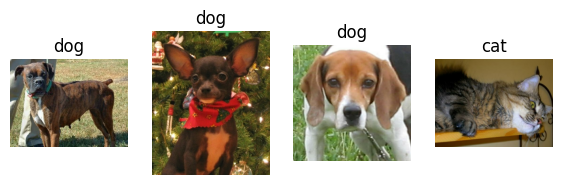

In [4]:
try:
    get_label_name = metadata.features['label'].int2str
    train_iter = iter(train_ds)
    fig = plt.figure(figsize=(7, 8))
    for x in range(4):
        image, label = next(train_iter)
        fig.add_subplot(1, 4, x + 1)
        plt.imshow(image)
        plt.axis('off')
        plt.title(get_label_name(label))
except StopIteration:
    print("Dataset iterator is empty!")

## Augmentation w/ Keras

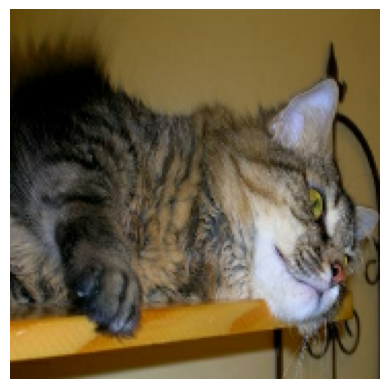

In [5]:
IMG_SIZE = 180

resize_and_rescale = Sequential([
  layers.Resizing(IMG_SIZE, IMG_SIZE),
  layers.Rescaling(1./255)
])

result = resize_and_rescale(image)
plt.axis('off')
plt.imshow(result);

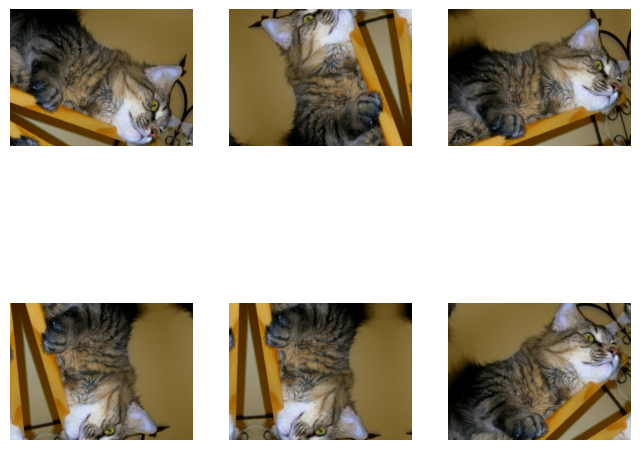

In [6]:
data_augmentation = Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.4),
])


plt.figure(figsize=(8, 7))
for i in range(6):
  augmented_image = data_augmentation(image)
  ax = plt.subplot(2, 3, i + 1)
  plt.imshow(augmented_image.numpy()/255)
  plt.axis("off")

## Simple ML model w/ augmentation

In [7]:
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

# Redefine data_augmentation here to ensure it uses the correct input shape
# (i.e., the resized image shape, 180x180x3) when applied in the map function.
data_augmentation = Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.4),
])

def prepare(ds, shuffle=False, augment=False):
  # Resize and rescale all datasets.
  ds = ds.map(lambda x, y: (resize_and_rescale(x), y),
              num_parallel_calls=AUTOTUNE)

  if shuffle:
    ds = ds.shuffle(1000)

  # Batch all datasets.
  ds = ds.batch(batch_size)

  # Use data augmentation only on the training set.
  if augment:
    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=AUTOTUNE)

  # Use buffered prefetching on all datasets.
  return ds.prefetch(buffer_size=AUTOTUNE)


train_ds = prepare(train_ds, shuffle=True, augment=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

In [8]:
model = Sequential([
    layers.Conv2D(32, (3, 3), input_shape=(180,180,3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
epochs=1
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


582/582 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.4961 - loss: 0.8248 - val_accuracy: 0.5185 - val_loss: 0.5764


In [10]:
loss, acc = model.evaluate(test_ds)

73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.5013 - loss: 0.5558


## Example of image augmentation w/ tf.image

In [20]:
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:70%]', 'train[70%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

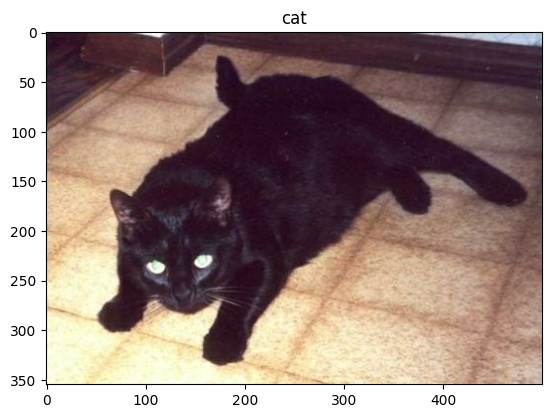

In [25]:
image, label = next(iter(val_ds))
plt.imshow(image)
plt.title(get_label_name(label));

In [26]:
def visualize(original, augmented):
    fig = plt.figure()
    plt.subplot(1,2,1)
    plt.title('Original image')
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title('Augmented image')
    plt.imshow(augmented)
    plt.axis("off")

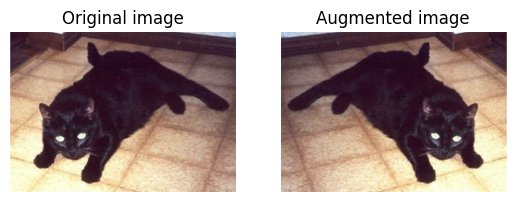

In [27]:
flipped = tf.image.flip_left_right(image)
visualize(image, flipped)

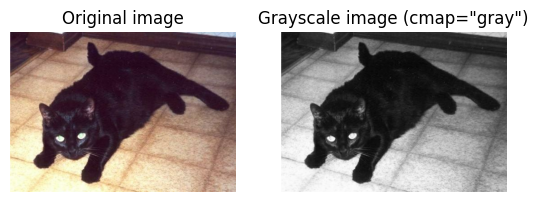

In [33]:
grayscaled = tf.image.rgb_to_grayscale(image)

def visualize_grayscale(original, augmented):
    fig = plt.figure()
    plt.subplot(1,2,1)
    plt.title('Original image')
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title('Grayscale image (cmap="gray")')
    # Explicitly set cmap='gray' to display in black and white
    plt.imshow(tf.squeeze(augmented), cmap='gray')
    plt.axis("off")

visualize_grayscale(image, grayscaled)

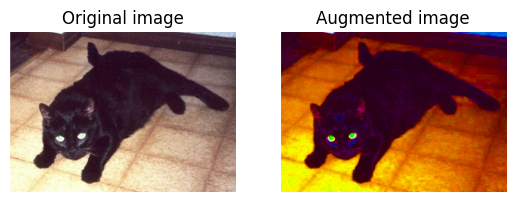

In [39]:
saturated = tf.image.adjust_saturation(image, 12)
visualize(image, saturated)

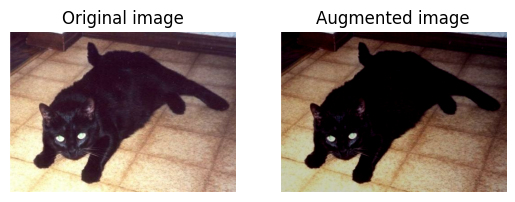

In [41]:
bright = tf.image.adjust_brightness(image, -0.2)
visualize(image, bright)

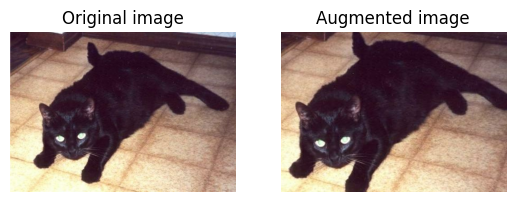

In [46]:
cropped = tf.image.central_crop(image, central_fraction=0.85)
visualize(image, cropped)

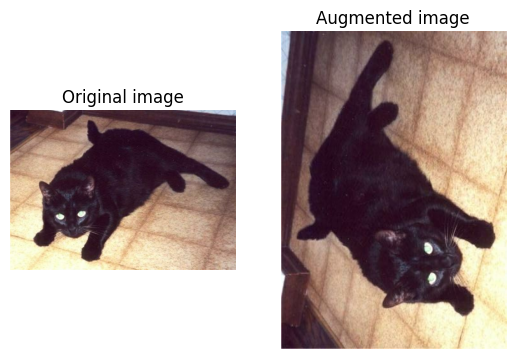

In [47]:
rotated = tf.image.rot90(image)
visualize(image, rotated)

## Image augmentation w/ Keras ImageDataGenerator

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 82s 0us/step


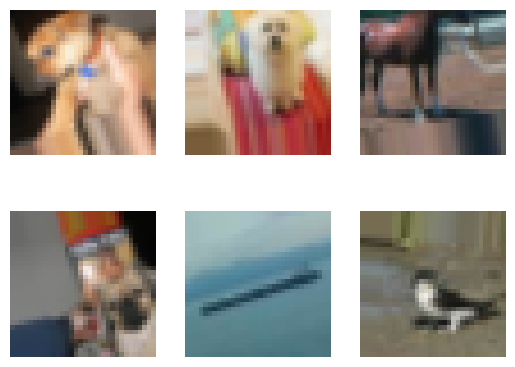

In [51]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

datagen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2)

datagen.fit(x_train)

for X_batch, y_batch in datagen.flow(x_train,y_train, batch_size=6):
    for i in range(0, 6):
        plt.subplot(2,3,i+1)
        plt.imshow(X_batch[i]/255)
        plt.axis('off')
    break